In [1]:
import glob
import pandas as pd
import random
import matplotlib.pyplot as plt
import numpy as np
import sys

/var/folders/5b/b2jjkdb55_g_qzx3lsl5k59m0000gn/T/ipykernel_22280/3278740220.py:2: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was too old on your system - pyarrow 10.0.1 is the current minimum supported version as of this release.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
import platform
import tensorflow as tf
# set memory growth for the GPU devices
physical_devices = tf.config.list_physical_devices('GPU')
for device in physical_devices:
    tf.config.experimental.set_memory_growth(device, True)

# check available devices
print(f"python platform: {platform.platform()}")
print(f"tensorflow version: {tf.__version__}")
print(f"keras version: {tf.keras.__version__}")
print(f"python {sys.version}")

gpu=len(tf.config.list_physical_devices('GPU'))>0
print("GPU is", "available" if gpu else "not available")
print("Num GPUs Available: ", len(physical_devices))

python platform: macOS-14.3.1-arm64-arm-64bit
tensorflow version: 2.9.0
keras version: 2.9.0
python 3.9.15 | packaged by conda-forge | (main, Nov 22 2022, 08:52:10) 
[Clang 14.0.6 ]
GPU is available
Num GPUs Available:  1


In [3]:
tf.config.list_physical_devices('GPU')

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [4]:
# Allow memory growth for each GPU
for gpu in physical_devices:
    print(gpu)
    tf.config.experimental.set_memory_growth(gpu, True)

PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [5]:
# specify directory path
cropped_resize_image_path = '../../../data/cropped_resize_images/'
# read all file names (abs directory)
cropped_resize_files = glob.glob(cropped_resize_image_path + '*')

In [6]:
# create a dataframe to store graph ids and chart type

# initialize the id and type lists
id_list=[]
type_list=[]
for i in range(len(cropped_resize_files)):
#     # open image file
#     image = Image.open(cropped_images_files[i])

#     # shgow the image
#     plt.imshow(image)
#     # close the axis for the image
#     plt.axis('off')
#     plt.show()

    # grab the id of the graph
    graph_id=cropped_resize_files[i].split('/')[-1].split('.')[0].split('_')[0]
    id_list.append(graph_id)
    # grab the type of 
    graph_type='_'.join(cropped_resize_files[i].split('/')[-1].split('.')[0].split('_')[1:])
    type_list.append(graph_type)
    
#     print(cropped_images_files[i])
    

# store graph IDs and types into df
gt_df=pd.DataFrame({'id':id_list,'type':type_list})
display(gt_df)

,id,type
0,1be6b04cd997,vertical_bar
1,8af5a9652f71,line
2,ee2ad65504a3,line
3,ed4ebde8e0c5,line
4,cd8895162fc3,line
...,...,...
60570,514a29bd0c92,line
60571,b7decb3da5c4,line
60572,d3416b1f2760,vertical_bar
60573,ba82863a4848,line


In [7]:
def path_type_corr(path_names:list) -> pd.DataFrame:
    '''
    create a dataframe that has two cols: path and type
    
    parameters:
        path_names: the list including all absolute paths
    '''
    types=[]
    
    for path in path_names:
        # grab the type of 
        graph_type='_'.join(path.split('/')[-1].split('.')[0].split('_')[1:])
        types.append(graph_type)
    
    df=pd.DataFrame({'path':path_names,'type':types})

    return df

In [8]:
# spit dataset into training set and validation set

# validation should be 20%
n=int(len(cropped_resize_files)*0.2)

# for test-set
test=random.sample(cropped_resize_files,n)

# for train-set
train=[i for i in cropped_resize_files if i not in test]

In [9]:
# create dataframe flow including abs paths and types for DataGenerator to load image

train_df=path_type_corr(train)
test_df=path_type_corr(test)

In [10]:
test_df

,path,type
0,../../../data/cropped_resize_images/978df7a50e...,scatter
1,../../../data/cropped_resize_images/5790c091b6...,line
2,../../../data/cropped_resize_images/7bc501de0e...,scatter
3,../../../data/cropped_resize_images/f47ffb78d4...,vertical_bar
4,../../../data/cropped_resize_images/4085965e00...,scatter
...,...,...
12110,../../../data/cropped_resize_images/4993a0a964...,dot
12111,../../../data/cropped_resize_images/68d9ca631d...,line
12112,../../../data/cropped_resize_images/9f6fe7b53e...,vertical_bar
12113,../../../data/cropped_resize_images/b5c62da87e...,scatter


In [11]:
# the images present in the datasets are 416x192px in size
img_height=416
img_width=192
batch_size=32

In [12]:
# provide a way to load images into batches and perform real-time data augmentation.
# usually done by dividing each pixel value by 255, so that they fall between 0 and 1, which can help in the training process.
# commonly used in image classification tasks
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img


train_datagen = ImageDataGenerator(rescale=1.0/255, # rescale the pixel values into [0,1]
#                                   zoom_range=0.2,
#                                   width_shift_range=0.2,
#                                   height_shift_range=0.2,
                                  fill_mode='nearest')


train_generator=train_datagen.flow_from_dataframe(train_df,
                                                x_col='path',
                                                y_col='type',
                                                target_size=(192, 416),
                                                batch_size=batch_size,
                                                  
                                                class_mode='categorical')

Found 48460 validated image filenames belonging to 5 classes.


In [13]:
test_datagen = ImageDataGenerator(rescale=1.0/255)


test_generator=train_datagen.flow_from_dataframe(test_df,
                                                x_col='path',
                                                y_col='type',
                                                batch_size=batch_size,
                                                target_size=(192, 416),
                                                class_mode='categorical')

Found 12115 validated image filenames belonging to 5 classes.


In [14]:
labels = {value: key for key, value in train_generator.class_indices.items()}

print("Label Mappings for classes present in the training and validation datasets\n")
for key, value in labels.items():
    print(f"{key} : {value}")

Label Mappings for classes present in the training and validation datasets

0 : dot
1 : horizontal_bar
2 : line
3 : scatter
4 : vertical_bar


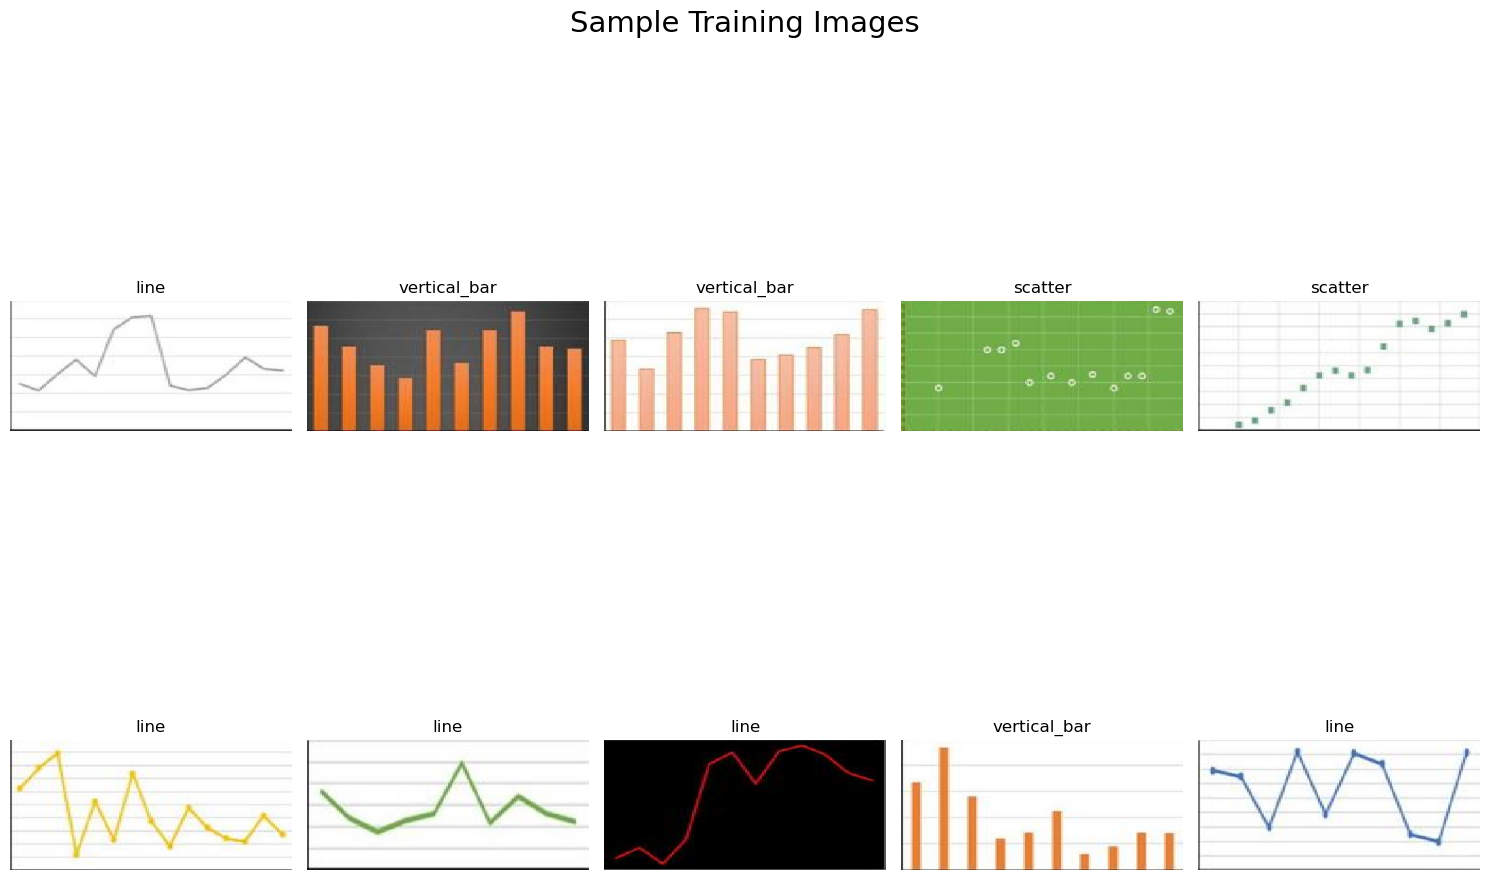

In [15]:
fig, ax = plt.subplots(nrows=2, ncols=5, figsize=(15, 12))
idx = 0

for i in range(2):
    for j in range(5):
        label = labels[np.argmax(train_generator[0][1][idx])]
        ax[i, j].set_title(f"{label}")
        ax[i, j].imshow(train_generator[0][0][idx][:, :, :])
        ax[i, j].axis("off")
        idx += 1

plt.tight_layout()
plt.suptitle("Sample Training Images", fontsize=21)
plt.show()

In [16]:
import tensorflow as tf
# allows you to create a neural network model as a sequence of layers.
# The Sequential class provides an easy way to define a linear stack of layers and is useful
from tensorflow.keras.models import Sequential
# allows you to apply an activation function to the output of a layer
from tensorflow.keras.layers import Activation
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import ModelCheckpoint

In [17]:
def create_model():
    model = Sequential([
        Conv2D(filters=128, kernel_size=(5, 5), padding='valid', input_shape=(192, 416, 3)),
        Activation('relu'),
        MaxPooling2D(pool_size=(2, 2)),
        BatchNormalization(),
        
        Conv2D(filters=64, kernel_size=(3, 3), padding='valid', kernel_regularizer=l2(0.00005)),
        Activation('relu'),
        MaxPooling2D(pool_size=(2, 2)),
        BatchNormalization(),
        
        Conv2D(filters=32, kernel_size=(3, 3), padding='valid', kernel_regularizer=l2(0.00005)),
        Activation('relu'),
        MaxPooling2D(pool_size=(2, 2)),
        BatchNormalization(),
        
        Flatten(),
        
        Dense(units=256, activation='relu'),
        Dropout(0.5),
        Dense(units=5, activation='softmax')
    ])
    
    return model

In [18]:
cnn_model = create_model()

Metal device set to: Apple M2 Max

systemMemory: 32.00 GB
maxCacheSize: 10.67 GB



2025-03-13 00:14:41.373971: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2025-03-13 00:14:41.374157: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [19]:
print(cnn_model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 188, 412, 128)     9728      
                                                                 
 activation (Activation)     (None, 188, 412, 128)     0         
                                                                 
 max_pooling2d (MaxPooling2D  (None, 94, 206, 128)     0         
 )                                                               
                                                                 
 batch_normalization (BatchN  (None, 94, 206, 128)     512       
 ormalization)                                                   
                                                                 
 conv2d_1 (Conv2D)           (None, 92, 204, 64)       73792     
                                                                 
 activation_1 (Activation)   (None, 92, 204, 64)       0

In [20]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [21]:
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',  # 监控指标
    factor=np.sqrt(0.1),  # 每次降低学习率 √0.1 ≈ 0.316 倍
    patience=5,  # 连续 5 轮 val_loss 不降才降低学习率
    min_lr=1e-6,  # 最小学习率，防止模型“学不动”
    verbose=1  # 显示学习率降低的日志
)

In [22]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy

In [23]:
optimizer = Adam(learning_rate=0.001)

In [24]:
cnn_model.compile(optimizer=optimizer, loss=CategoricalCrossentropy(), metrics=['accuracy'])

In [25]:
checkpoint = ModelCheckpoint(
    filepath="checkpoints/best_model.h5",  # 只保存 1 个最佳模型
    monitor='val_accuracy',  # 监控 val_accuracy
    save_best_only=True,  # 只保存最佳模型
    save_weights_only=False,  # 保存整个模型（包括结构 + 权重 + 优化器状态）
    mode='max',  # val_accuracy 越大越好
    verbose=1  # 训练时打印 checkpoint 信息
)

In [26]:
history = cnn_model.fit(
    train_generator,
    epochs=10,  # 训练 50 轮
    validation_data=test_generator,
    verbose=2,
    callbacks=[reduce_lr, checkpoint]  
)

Epoch 1/10


2025-03-13 00:14:41.673835: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz
2025-03-13 00:14:41.957631: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2025-03-13 00:18:38.345857: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.



Epoch 1: val_accuracy improved from -inf to 0.67701, saving model to checkpoints/best_model.h5
1515/1515 - 255s - loss: 0.7745 - accuracy: 0.8895 - val_loss: 1.4882 - val_accuracy: 0.6770 - lr: 0.0010 - 255s/epoch - 168ms/step
Epoch 2/10

Epoch 2: val_accuracy improved from 0.67701 to 0.87850, saving model to checkpoints/best_model.h5
1515/1515 - 261s - loss: 0.1641 - accuracy: 0.9471 - val_loss: 0.3000 - val_accuracy: 0.8785 - lr: 0.0010 - 261s/epoch - 173ms/step
Epoch 3/10

Epoch 3: val_accuracy improved from 0.87850 to 0.94214, saving model to checkpoints/best_model.h5
1515/1515 - 250s - loss: 0.1425 - accuracy: 0.9628 - val_loss: 0.2525 - val_accuracy: 0.9421 - lr: 0.0010 - 250s/epoch - 165ms/step
Epoch 4/10

Epoch 4: val_accuracy did not improve from 0.94214
1515/1515 - 250s - loss: 0.0831 - accuracy: 0.9811 - val_loss: 0.4734 - val_accuracy: 0.8320 - lr: 0.0010 - 250s/epoch - 165ms/step
Epoch 5/10

Epoch 5: val_accuracy did not improve from 0.94214
1515/1515 - 250s - loss: 0.072